Install & Import Libraries


In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'numpy', 'matplotlib', 'seaborn',
                'scikit-learn', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──
sns.set_style("whitegrid")
sns.set_palette("Set1")
plt.rcParams.update({'figure.figsize': (12, 7),
                     'font.size': 12,
                     'axes.titlesize': 14,
                     'axes.titleweight': 'bold'})

# ── Version check ──
print("=" * 50)
print("📦 LIBRARY VERSIONS")
print("=" * 50)
print(f"  Pandas:     {pd.__version__}")
print(f"  NumPy:      {np.__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")
print(f"  Seaborn:    {sns.__version__}")
print("=" * 50)
print("✅ All libraries ready!")

📦 LIBRARY VERSIONS
  Pandas:     2.2.2
  NumPy:      2.0.2
  Matplotlib: 3.10.0
  Seaborn:    0.13.2
✅ All libraries ready!


Load Iris Datasets

In [2]:
iris_raw = load_iris()

# Build DataFrame
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

print(" Dataset loaded successfully!")
print(f"\n  Shape        : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} cols)")
print(f"  Features     : {list(df.columns[:-1])}")
print(f"  Target col   : '{df.columns[-1]}'")
print(f"  Species      : {df['species'].cat.categories.tolist()}")
print(f"  Samples/class: 50 each (perfectly balanced)")

 Dataset loaded successfully!

  Shape        : (150, 5)  (150 rows × 5 cols)
  Features     : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Target col   : 'species'
  Species      : ['setosa', 'versicolor', 'virginica']
  Samples/class: 50 each (perfectly balanced)


Inspect Dataset


In [3]:
print("━" * 60)
print(" FIRST 5 ROWS (.head())")
print("━" * 60)
print(df.head())

print("\n" + "━" * 60)
print(" LAST 5 ROWS (.tail())")
print("━" * 60)
print(df.tail())

print("\n" + "━" * 60)
print(" RANDOM SAMPLE of 5 (.sample())")
print("━" * 60)
print(df.sample(5, random_state=42))

print("\n" + "━" * 60)
print(" DATA TYPES (.dtypes)")
print("━" * 60)
for col in df.columns:
    print(f"  {col:35}  →  {df[col].dtype}")

print("\n" + "━" * 60)
print(" DATASET INFO (.info())")
print("━" * 60)
df.info()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FIRST 5 ROWS (.head())
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 LAST 5 ROWS (.tail())
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   

Descriptive Statistics + Missing Values

In [4]:
print("=" * 70)
print(" DESCRIPTIVE STATISTICS (.describe())")
print("=" * 70)
print(df.describe().round(3).to_string())

print("\n" + "=" * 70)
print(" MISSING VALUES")
print("=" * 70)
missing = df.isnull().sum()
print(missing.to_string())
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print(" Dataset is PERFECTLY CLEAN — no missing values!")

print("\n" + "=" * 70)
print(" CLASS DISTRIBUTION")
print("=" * 70)
counts = df['species'].value_counts()
pcts   = df['species'].value_counts(normalize=True).mul(100).round(2)
for sp in counts.index:
    print(f"  {sp:15}: {counts[sp]:3d} samples ({pcts[sp]:.1f}%)")
print("\n Perfectly balanced — 50 samples per class (33.33% each)")

print("\n" + "=" * 70)
print(" PER-SPECIES STATISTICS")
print("=" * 70)
numeric_cols = ['sepal length (cm)', 'sepal width (cm)',
                'petal length (cm)', 'petal width (cm)']
print(df.groupby('species')[numeric_cols].mean().round(2).to_string())

 DESCRIPTIVE STATISTICS (.describe())
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count            150.000           150.000            150.000           150.000
mean               5.843             3.057              3.758             1.199
std                0.828             0.436              1.765             0.762
min                4.300             2.000              1.000             0.100
25%                5.100             2.800              1.600             0.300
50%                5.800             3.000              4.350             1.300
75%                6.400             3.300              5.100             1.800
max                7.900             4.400              6.900             2.500

 MISSING VALUES
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0

Total missing values: 0
 Dataset is PERFECTLY CLEAN — no missing values!

 CLASS DISTRIBUTION
  setosa       

Scatter Plots — Feature Relationships

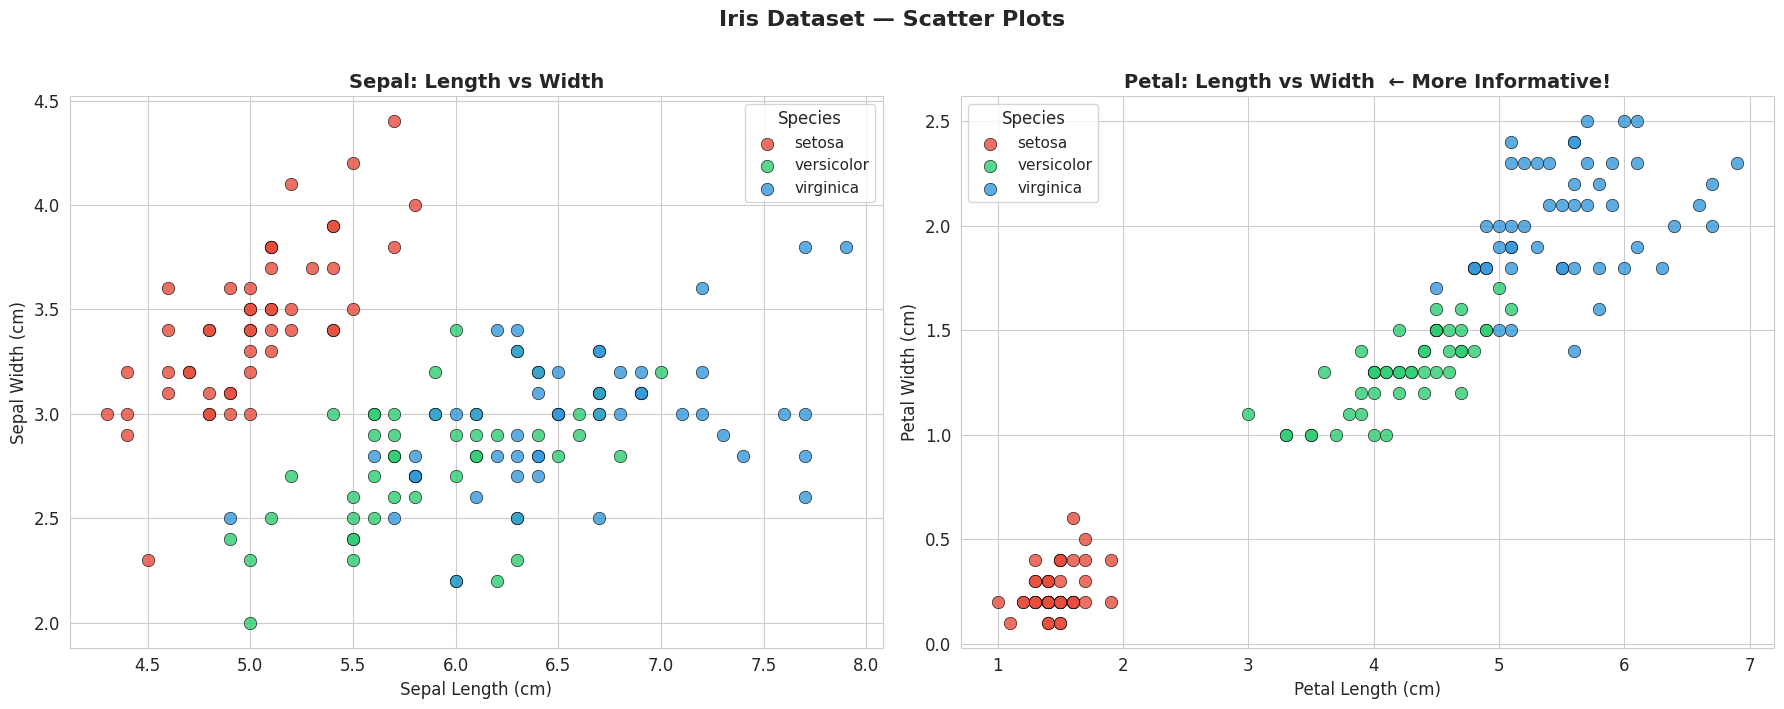

 Saved: task1_scatter_plots.png

 KEY INSIGHT:
   Petal features (right plot) show MUCH cleaner separation.
   Setosa is completely isolated — linearly separable.
   Sepal features (left plot) have significant overlap.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = {'setosa': '#E74C3C', 'versicolor': '#2ECC71', 'virginica': '#3498DB'}

for species in df['species'].unique():
    sub = df[df['species'] == species]

    # ── Plot 1: Sepal features ──
    axes[0].scatter(sub['sepal length (cm)'], sub['sepal width (cm)'],
                    label=species, color=colors[str(species)],
                    alpha=0.8, s=80, edgecolors='black', linewidth=0.5)

    # ── Plot 2: Petal features ──
    axes[1].scatter(sub['petal length (cm)'], sub['petal width (cm)'],
                    label=species, color=colors[str(species)],
                    alpha=0.8, s=80, edgecolors='black', linewidth=0.5)

axes[0].set(title='Sepal: Length vs Width',
            xlabel='Sepal Length (cm)', ylabel='Sepal Width (cm)')
axes[0].legend(title='Species', fontsize=11)

axes[1].set(title='Petal: Length vs Width  ← More Informative!',
            xlabel='Petal Length (cm)', ylabel='Petal Width (cm)')
axes[1].legend(title='Species', fontsize=11)

plt.suptitle('Iris Dataset — Scatter Plots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task1_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: task1_scatter_plots.png")
print("\n KEY INSIGHT:")
print("   Petal features (right plot) show MUCH cleaner separation.")
print("   Setosa is completely isolated — linearly separable.")
print("   Sepal features (left plot) have significant overlap.")

Histograms — Value Distributions

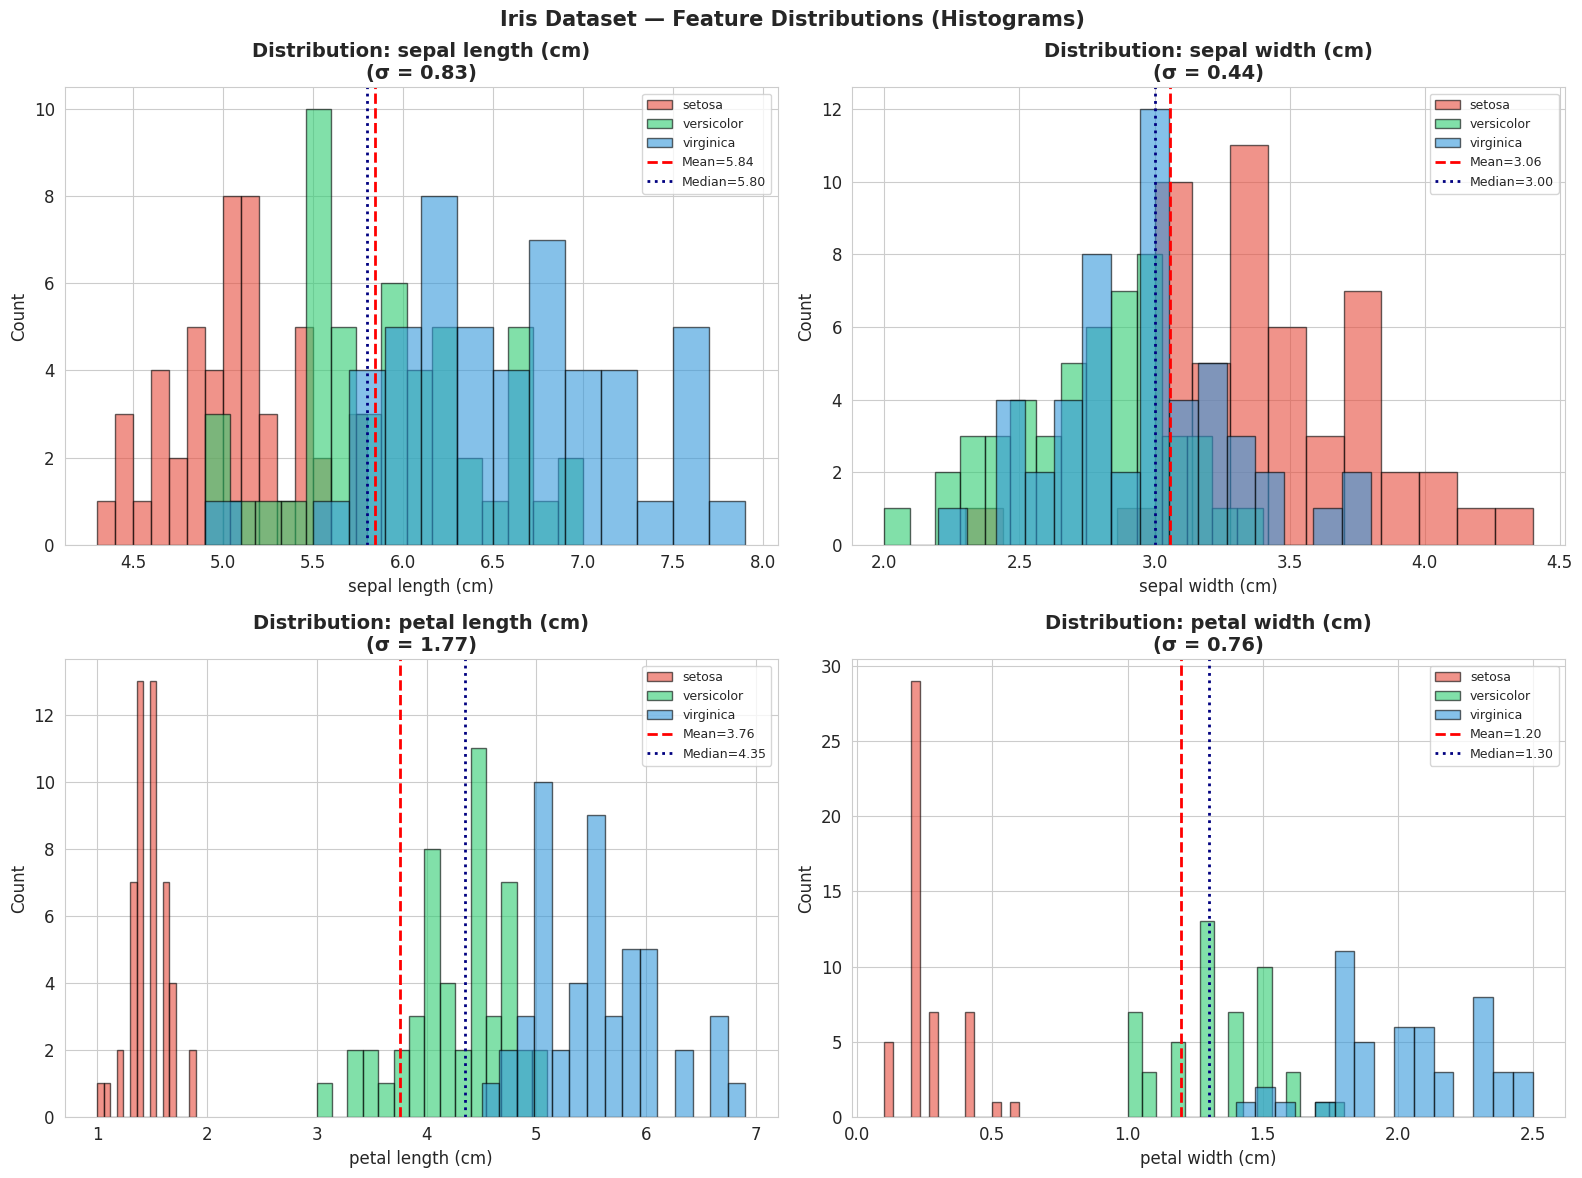

Saved: task1_histograms.png

 KEY INSIGHT:
   Petal features show BIMODAL distribution (two peaks).
   Setosa cluster (small petals) vs Versicolor/Virginica (larger).
   Sepal Width is roughly NORMAL — standard bell curve.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

species_colors = {'setosa':'#E74C3C','versicolor':'#2ECC71','virginica':'#3498DB'}

for i, col in enumerate(numeric_cols):
    for species in df['species'].unique():
        sub = df[df['species'] == species]
        axes[i].hist(sub[col], bins=15, alpha=0.6, label=str(species),
                     color=species_colors[str(species)], edgecolor='black', lw=0.5)

    mean_v   = df[col].mean()
    median_v = df[col].median()
    std_v    = df[col].std()

    axes[i].axvline(mean_v,   color='red',  linestyle='--', lw=2,
                    label=f'Mean={mean_v:.2f}')
    axes[i].axvline(median_v, color='navy', linestyle=':',  lw=2,
                    label=f'Median={median_v:.2f}')

    axes[i].set_title(f'Distribution: {col}\n(σ = {std_v:.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Iris Dataset — Feature Distributions (Histograms)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: task1_histograms.png")
print("\n KEY INSIGHT:")
print("   Petal features show BIMODAL distribution (two peaks).")
print("   Setosa cluster (small petals) vs Versicolor/Virginica (larger).")
print("   Sepal Width is roughly NORMAL — standard bell curve.")

Box Plots — Outlier Detection

 OUTLIER REPORT (IQR Method: 1.5×IQR rule)
  sepal length (cm)             :  0 outliers | CLEAN
  sepal width (cm)              :  4 outliers |   OUTLIERS
  petal length (cm)             :  0 outliers | CLEAN
  petal width (cm)              :  0 outliers | CLEAN

  Total: 4 outliers across all features


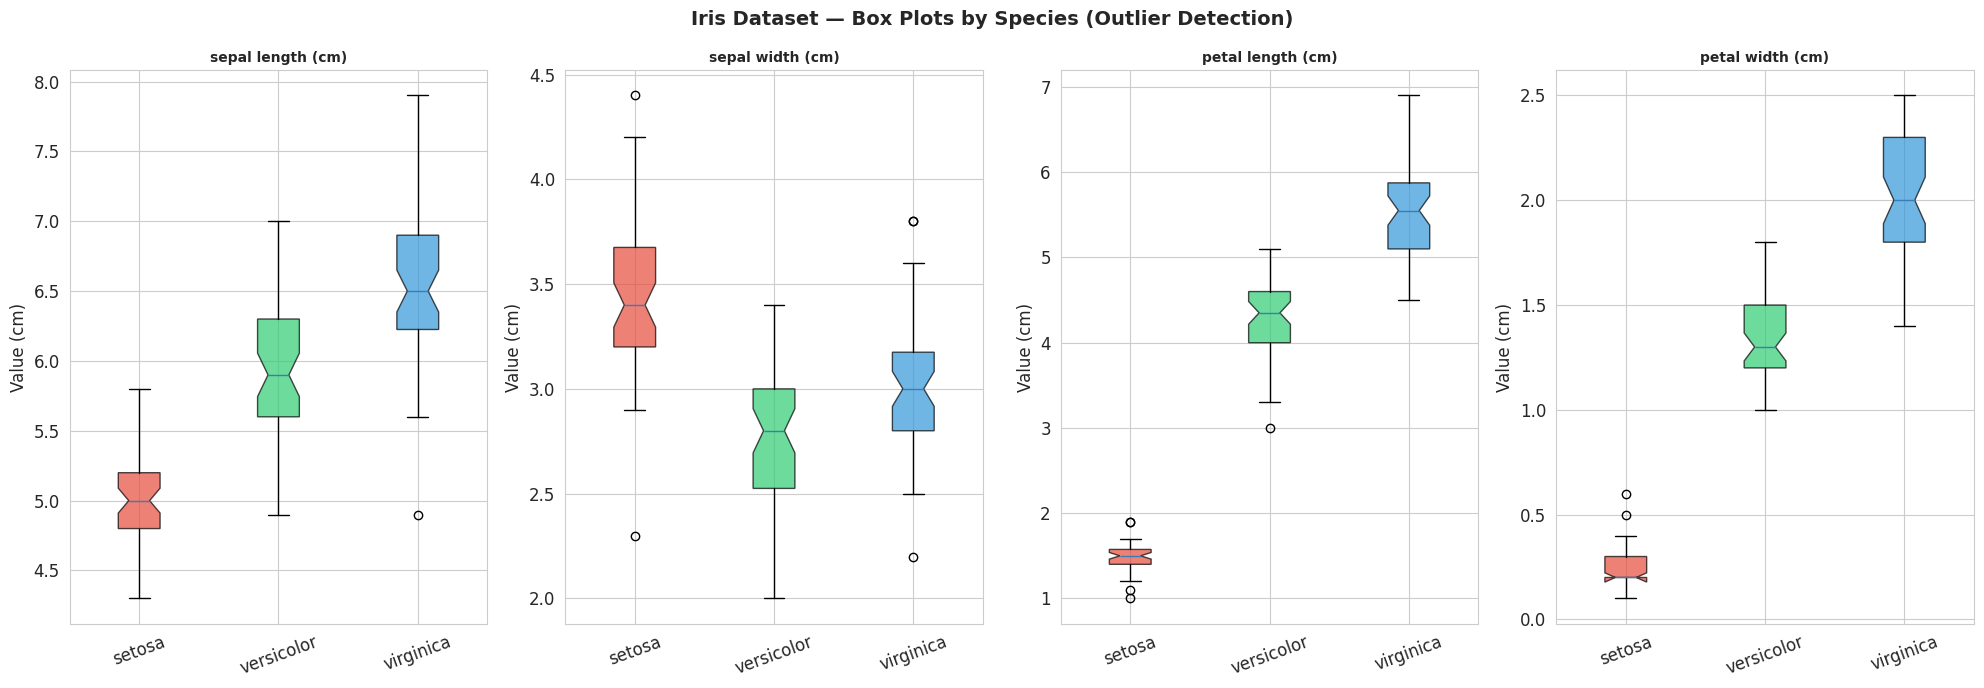

 Saved: task1_box_plots.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))
species_list = df['species'].unique().tolist()

for i, col in enumerate(numeric_cols):
    data_per_class = [df[df['species'] == sp][col].values
                      for sp in species_list]

    bp = axes[i].boxplot(data_per_class, patch_artist=True,
                          labels=[str(s) for s in species_list],
                          notch=True, showfliers=True)

    box_colors = ['#E74C3C', '#2ECC71', '#3498DB']
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value (cm)')
    axes[i].tick_params(axis='x', rotation=20)

# ── Outlier Report ──
print("=" * 55)
print(" OUTLIER REPORT (IQR Method: 1.5×IQR rule)")
print("=" * 55)
total = 0
for col in numeric_cols:
    q1, q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr     = q3 - q1
    out_cnt = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    total  += out_cnt
    status  = "  OUTLIERS" if out_cnt > 0 else "CLEAN"
    print(f"  {col[:30]:30}: {out_cnt:2d} outliers | {status}")
print(f"\n  Total: {total} outliers across all features")

plt.suptitle('Iris Dataset — Box Plots by Species (Outlier Detection)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_box_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: task1_box_plots.png")

Correlation Heatmap

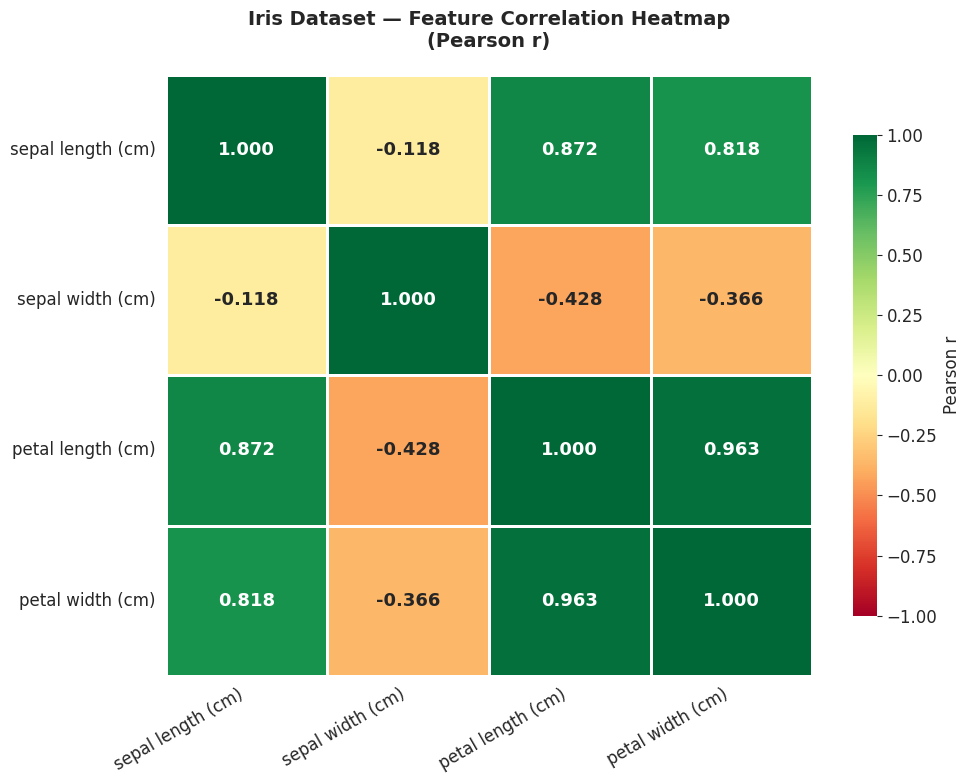

 TOP CORRELATIONS
  sepal  ↔ sepal : r=-0.118  |  Weak Negative
  petal  ↔ sepal : r=+0.872  |  Very Strong Positive
  petal  ↔ sepal : r=-0.428  |  Moderate Negative
  petal  ↔ petal : r=+0.963  |  Very Strong Positive
  petal  ↔ sepal : r=+0.818  |  Very Strong Positive
  petal  ↔ sepal : r=-0.366  |  Weak Negative


In [8]:
corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    ax=ax, linewidths=1, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Iris Dataset — Feature Correlation Heatmap\n(Pearson r)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('task1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interpret ──
print("=" * 60)
print(" TOP CORRELATIONS")
print("=" * 60)
for col_a in numeric_cols:
    for col_b in numeric_cols:
        if col_a < col_b:
            r = corr_matrix.loc[col_a, col_b]
            strength = ("Very Strong" if abs(r)>.7 else
                        "Moderate" if abs(r)>.4 else "Weak")
            direction = "Positive" if r > 0 else "Negative"
            print(f"  {col_a.split()[0]:6} ↔ {col_b.split()[0]:6}: "
                  f"r={r:+.3f}  |  {strength} {direction}")

Task 1 Final Summary

In [10]:
r_petal = corr_matrix.loc['petal length (cm)', 'petal width (cm)']


print(" TASK 1 — FINAL SUMMARY (Iris EDA)")

print(f"""
  Dataset      : Iris (Ronald Fisher, 1936)
  Samples      : {df.shape[0]}
  Features     : {len(numeric_cols)} numeric
  Classes      : {df['species'].nunique()} species
  Missing Data : {df.isnull().sum().sum()} (NONE — perfectly clean)
  Balanced     : Yes (50 per class)

  KEY FINDINGS:
  1. Iris Setosa is LINEARLY SEPARABLE by petal features
  2. Petal Length ↔ Petal Width: r={r_petal:.3f} (highest correlation)
  3. Sepal Width is nearly INDEPENDENT of other features
  4. Petal features >> Sepal features for classification tasks
  5. Minor outliers in Sepal Width — does not affect analysis

  FILES SAVED:
   task1_scatter_plots.png
   task1_histograms.png
   task1_box_plots.png
   task1_pair_plot.png
   task1_correlation_heatmap.png
""")


 TASK 1 — FINAL SUMMARY (Iris EDA)

  Dataset      : Iris (Ronald Fisher, 1936)
  Samples      : 150
  Features     : 4 numeric
  Classes      : 3 species
  Missing Data : 0 (NONE — perfectly clean)
  Balanced     : Yes (50 per class)

  KEY FINDINGS:
  1. Iris Setosa is LINEARLY SEPARABLE by petal features
  2. Petal Length ↔ Petal Width: r=0.963 (highest correlation)
  3. Sepal Width is nearly INDEPENDENT of other features
  4. Petal features >> Sepal features for classification tasks
  5. Minor outliers in Sepal Width — does not affect analysis

  FILES SAVED:
   task1_scatter_plots.png
   task1_histograms.png
   task1_box_plots.png
   task1_pair_plot.png
   task1_correlation_heatmap.png

